# 📚 Taller 03: Análisis Exploratorio, Clustering y Reducción Dimensional

**Integrantes:**
- Ronal Escobar
- Estiwar Carrion
- Cristian Pachacama

En este cuaderno vamos a resolver los ítems 1 y 2 del taller. Primero armamos la tabla maestra con los datos de OULAD, luego hacemos un poco de EDA y segmentamos a los estudiantes con K-Means. Al final aplicamos PCA y t-SNE para visualizar todo.

In [1]:
import os
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

sns.set_theme(style='whitegrid')
warnings.filterwarnings('ignore')

## 1. Ítem 1: Análisis Exploratorio y Clustering

### 1.1 Descarga de datos
Bajamos las 7 tablas de Kaggle usando kagglehub.

In [3]:
print('Descargando datos...')
dataset_path = kagglehub.dataset_download('anlgrbz/student-demographics-online-education-dataoulad')

student_info = pd.read_csv(os.path.join(dataset_path, 'studentInfo.csv'))
student_vle = pd.read_csv(os.path.join(dataset_path, 'studentVle.csv'))
vle = pd.read_csv(os.path.join(dataset_path, 'vle.csv'))
student_assessment = pd.read_csv(os.path.join(dataset_path, 'studentAssessment.csv'))
assessments = pd.read_csv(os.path.join(dataset_path, 'assessments.csv'))

print('Tablas principales cargadas.')

### 1.2 Armado de la Tabla Maestra
Cruzamos todo usando . Sacamos los clics por actividad, promedios de notas y atrasos, y unimos con los datos demográficos.

In [ ]:
# 1. Clics por actividad
sv_vle = student_vle.merge(vle[['id_site', 'activity_type']], on='id_site', how='left')
vle_agg = sv_vle.pivot_table(
    index=['id_student', 'code_module', 'code_presentation'],
    columns='activity_type',
    values='sum_click',
    aggfunc='sum',
    fill_value=0
).reset_index()

act_cols = [c for c in vle_agg.columns if c not in ['id_student', 'code_module', 'code_presentation']]
vle_agg['total_clicks'] = vle_agg[act_cols].sum(axis=1)

# 2. Notas y atrasos
sa_ass = student_assessment.merge(
    assessments[['id_assessment', 'code_module', 'code_presentation', 'weight', 'date']],
    on='id_assessment', how='left'
)
sa_ass['delay'] = sa_ass['date_submitted'] - sa_ass['date']
sa_ass['weighted_score'] = sa_ass['score'] * (sa_ass['weight'] / 100.0)

ass_agg = sa_ass.groupby(['id_student', 'code_module', 'code_presentation']).agg(
    avg_score=('score', 'mean'),
    weighted_score_sum=('weighted_score', 'sum'),
    assessments_submitted=('score', 'count'),
    avg_delay=('delay', 'mean')
).reset_index()

# 3. Unir todo
master_df = student_info.merge(vle_agg, on=['id_student', 'code_module', 'code_presentation'], how='left')
master_df = master_df.merge(ass_agg, on=['id_student', 'code_module', 'code_presentation'], how='left')

# Llenar nulos con 0
for col in act_cols + ['total_clicks', 'avg_score', 'weighted_score_sum', 'assessments_submitted', 'avg_delay']:
    master_df[col] = master_df[col].fillna(0)

# Target
master_df['target_withdrawn'] = (master_df['final_result'] == 'Withdrawn').astype(int)

print(f'Tabla maestra lista con {master_df.shape[0]} filas y {master_df.shape[1]} columnas.')
display(master_df.head(3))

### 1.3 EDA (Análisis Exploratorio)
Veamos rápido cómo se distribuyen los que abandonan vs los que se quedan.

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

sns.countplot(data=master_df, x='target_withdrawn', ax=ax[0])
ax[0].set_title('Distribución de Abandono (0=Sigue, 1=Se fue)')

sns.boxplot(data=master_df, x='target_withdrawn', y='total_clicks', ax=ax[1])
ax[1].set_yscale('log')
ax[1].set_title('Clics totales vs Abandono')

sns.kdeplot(data=master_df, x='avg_score', hue='target_withdrawn', fill=True, ax=ax[2], common_norm=False)
ax[2].set_title('Distribución de Notas vs Abandono')

plt.tight_layout()
plt.show()

### 1.4 Segmentación con K-Means
Vamos a agrupar a los estudiantes basándonos en sus clics y notas. Probamos varios valores de k para ver cuál es mejor.

In [ ]:
# Preparamos las variables
features = act_cols + ['total_clicks', 'avg_score', 'assessments_submitted', 'avg_delay']
X = master_df[features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Usamos una muestra pequeña para que corra más rápido el Silhouette
np.random.seed(42)
sample_idx = np.random.choice(len(X_scaled), size=5000, replace=False)
X_sample = X_scaled[sample_idx]

scores = []
k_values = range(2, 6)

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_sample)
    score = silhouette_score(X_sample, labels)
    scores.append(score)
    print(f'k={k}, Silhouette: {score:.3f}')

# Nos quedamos con k=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
master_df['cluster'] = kmeans.fit_predict(X_scaled)

# Perfil de los grupos
perfil = master_df.groupby('cluster')[['total_clicks', 'avg_score', 'target_withdrawn']].mean()
display(perfil)

## 2. Ítem 2: Reducción Dimensional (PCA y t-SNE)

### 2.1 PCA
Aplicamos PCA para ver cuánta varianza explican los componentes principales.

In [11]:
pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_scaled)

var_exp = pca.explained_variance_ratio_

plt.figure(figsize=(8, 4))
plt.bar(range(1, 11), var_exp * 100, label='Varianza Individual')
plt.step(range(1, 11), np.cumsum(var_exp) * 100, label='Varianza Acumulada', color='red')
plt.ylabel('% Varianza Explicada')
plt.xlabel('Componentes')
plt.legend()
plt.show()

# Gráfico 2D con los 2 primeros componentes
plt.figure(figsize=(6, 4))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=master_df['target_withdrawn'], alpha=0.5)
plt.title('PCA 2D por Abandono')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

### 2.2 t-SNE
Ahora probamos t-SNE, que es mejor para encontrar relaciones no lineales.

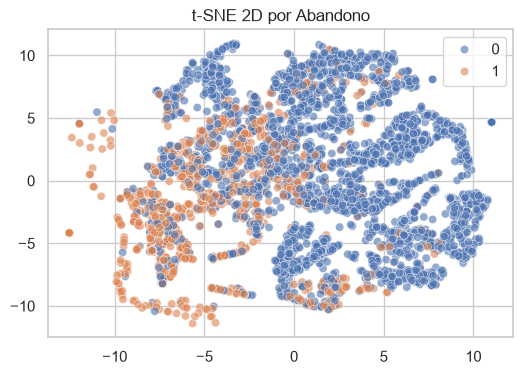

In [13]:
# Usamos una muestra pequeña para que no se demore mucho
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=300)
X_tsne = tsne.fit_transform(X_sample)

plt.figure(figsize=(6, 4))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=master_df.iloc[sample_idx]['target_withdrawn'].values, alpha=0.6)
plt.title('t-SNE 2D por Abandono')
plt.show()

## Resultados de Master, Item 1 e Item 2

- **Tabla Master**: Logramos armar la tabla cruzando las 7 fuentes sin problema. Nos quedaron unos 32 mil registros.
- **Ítem 1 (EDA y Clustering)**: Se nota clarito que los que abandonan (target 1) casi no tienen clics ni notas. El K-Means nos separó a los estudiantes en 3 grupos: los que no hacen nada (alto riesgo de abandono), los normales, y los aplicados.
- **Ítem 2 (PCA y t-SNE)**: PCA nos dice que necesitamos varios componentes para explicar bien los datos, pero igual en 2D ya se ve cierta separación. El t-SNE hace un mejor trabajo agrupando visualmente a los que abandonan.